# Physics 229 Experiment 1 - Convective and Radiative Cooling

Name: Mufaro Machaya

Partner: Eric Hu

## January 7 - (Lab Session 1) Setup and Initial Exploration

**Background Information:** (From the lab manual:) This experiment is about modeling conduction, radiation, and convection. Conduction follows the model
$$\frac{d Q}{d t} = -k A \frac{d T}{d x}$$
where $k$ is the thermal conductivity of the material and $A$ is the cross-sectional area. Radiation follows the model
$$\frac{d Q}{d t} = A \varepsilon \sigma (T_0^4 - T^4)$$
where $\varepsilon$ is the emissivity of the material and $\sigma \approx 5.6703 \times 10^{-8}$ $W m^{-2} K^{-4}$ is the Stefan-Boltzmann constant. Lastly, convection follows the model
$$\frac{d Q}{d t} = -h A (T - T_0)$$
where $h$ is a proportionality constant dependent on the temperature difference (and seemingly the geometry of the model), and for a cylinder, this is
$$h = \left( 1.32 \frac{J}{m^{7/4} s K^{5/4}} \right) \left( \frac{T - T_0}{D} \right)^{1/4}$$
where $D$ is the diameter.

Altogether, these equations can be related to the rate of cooling with
$$\frac{d Q}{d t} = MC \frac{d T}{d t} = \rho V C \frac{d T}{d t}$$
where $M$ is the mass of the pipe, $\rho$ is the density, $C$ is the constant-volume specific heat, and $V$ is the colume. 

**Experimental Goals:**

> **Instructions for Week 01**
> * Interact with the equipment to determine what sorts of quantities you can vary and how measurements might be performed. Consider measurement range, precision, sources of noise, and systematic uncertainties, as appropriate.
> * Develop an experimental objective (what is your big-picture experimental goal?
> * Try to come up with at least two different procedures. For each procedure, consider the steps and equations needed to get from raw data to a final result.
> * Collect a small set of test data (with uncertainties) for your most promising procedure.
> * Run these data through your data analysis procedure to see how things work out, including uncertainties in your results.
> * If you have time, repeat the above for one of your other procedures.
> 
> For your experimental objective, focus on an experimentally determined quantity of interest:
> * Find a quantity that can be extracted from fitting parameters such as slope, y-intercept or from nonlinear models. Consider which of your measured variables you are plotting on your x- and y-axes.
> * Can you compare your quantity of interest to an expected value or a value that can be determined using an entirely different experimental procedure?

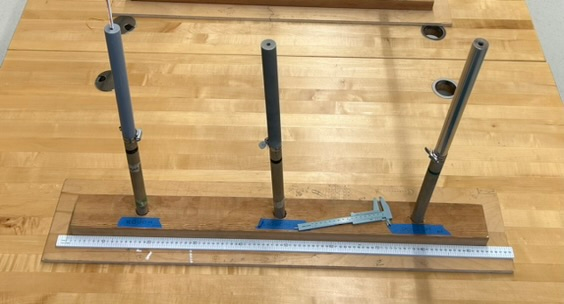

In short, we need to explore the system and try and come up with an interesting research question. We should try and identify an independent variable (just one) and some dependent variable(s) alongside a simple research question. It should be something easily measurable.

We're doing cooling across three aluminum rods of different emissivities, so we can model the cooling across all three rods and determine their emissivity as a function of the material. They're all aluminum and the same shape, so they should each have a thermal conductivity of roughly $k \approx 237$ $W m^{-1} K^{-1}$ [[1]](https://www.engineeringtoolbox.com/thermal-conductivity-metals-d_858.html) and a cylindrical proportionality constant $h$.

### Basis Functions

**Note:** Again, I'll be using my developed personal library of functions from Physics 219 (viewable from [this link](https://raw.githubusercontent.com/mufaro3/physics-219/refs/heads/main/radio/common.py)).

In [1]:
from common import *
from scipy.integrate import solve_ivp
import scipy
import serial, csv, time
from datetime import datetime

First, we can write the proportionality constant:
$$h = \left( 1.32 \frac{J}{m^{7/4} s K^{5/4}} \right) \left( \frac{T - T_0}{D} \right)^{1/4}$$

In [2]:
def calculate_proportionality_constant(object_temp, surround_temp, diameter):
    """
    Calculates the cylindrical proportionality constant 'h' for the object given the diameter.
    """
    temp_grad = object_temp - surround_temp
    return np.sign(temp_grad) * 1.32 * (np.abs(temp_grad) / diameter) ** (1/4)

Then our differential equations, starting with conduction
$$\frac{d Q}{d t} = -k A \frac{d T}{d x}$$

In [3]:
def calculate_heat_transfer_conduction(thermal_conductivity, cross_section_surface_area, temp_gradient):
    """
    Calculates the convective heat transfer based on the temperature gradient
    """
    return -thermal_conductivity * cross_section_surface_area * temp_gradient

def calculate_heat_transfer_conduction_curry(thermal_conductivity, cross_section_surface_area):
    return lambda temp_gradient: calculate_heat_transfer_conduction(
        thermal_conductivity, cross_section_surface_area, temp_gradient)

Next, radiation
$$\frac{d Q}{d t} = A \varepsilon \sigma (T_0^4 - T^4)$$

In [4]:
def calculate_heat_transfer_radiation(cross_section_surface_area, emissivity, object_temp, surround_temp):
    """
    Calculates the radiative heat transfer based on the temperature
    """
    return cross_section_surface_area * emissivity * scipy.constants.Stefan_Boltzmann * \
        (surround_temp ** 4 - object_temp ** 4)

def calculate_heat_transfer_radiation_curry(cross_section_surface_area, surround_temp):
    return lambda object_temp, emissivity: calculate_heat_transfer_radiation(
        cross_section_surface_area, emissivity, object_temp, surround_temp)

And lastly, convection:
$$\frac{d Q}{d t} = -h A (T - T_0)$$

In [5]:
def calculate_heat_transfer_convection(proportionality_constant, cross_section_surface_area, object_temp, surround_temp):
    """
    Calculates the convective heat transfer
    """
    return -proportionality_constant * cross_section_surface_area * (object_temp - surround_temp)

We can curry this function to make it a function of only the temperature

In [6]:
def calculate_heat_transfer_convection_curry(cross_section_surface_area, surround_temp, diameter):
    return lambda object_temp: \
        calculate_heat_transfer_convection(
            calculate_proportionality_constant(object_temp, surround_temp, diameter),
            cross_section_surface_area, object_temp, surround_temp
        )

**Experimental Overview/Plan:** So, we've decided that our independent variable will be the finish of the material (rough, smooth, or lacquered), and the dependent variable will be the emissivity, and our goal for this experiment will be to characterize the relationship between the finish and the emissivity (i.e., which finish has the highest/lowest emissivity, and what does this mean for the building of thermal materials?).

To do this, we'll heat up each of the rods to a set temperature $T_{max}$ then cool them back down to lab temperature $T_0$ and measure the data as a function of time to obtain a cooling curve for the pipe. We'll then approximate the emissivity of the material from the cooling curve by embedding the differential equations into `solve_ivp` and estimating the emissivity with `curve_fit` with uncertainty.

The most difficult portion of this experiment will be data collection, which should be automated for ease.

**Constant Measurements:** Next, we're going to measure a bunch of set constants about the pipes to begin with, so that we can calculate further values later.

*Rough Pipe:*

* Outer Diameter of Rough Pipe: $D = 2.5 \pm 0.1$ cm
* Inner Diameter of the Rough Pipe: $0.7 \pm 0.1$ cm
* Height of the Rough Pipe (excluding the wooden base): $30.4 \pm 0.1$ cm

*Smooth Pipe:*

* Outer Diameter of Smooth Pipe: $D = 2.5 \pm 0.1$ cm
* Inner Diameter of Smooth Pipe: $0.7 \pm 0.1$ cm
* Height of the Smooth Pipe (excluding the wooden base): $30.4 \pm 0.1$ cm

*Lacquered Pipe:*

* Outer Diameter of Lacquered Pipe: $D = 2.5 \pm 0.1$ cm
* Inner Diameter of Lacquered Pipe: $0.7 \pm 0.1$ cm
* Height of the Lacquered Pipe (excluding the wooden base): $30.2 \pm 0.1$ cm


*Aluminum:*

* Thermal Conductivity of Aluminum: $k = 237$ $\mathrm{W m^{-1} K^{-1}}$ [[1]](https://www.engineeringtoolbox.com/thermal-conductivity-metals-d_858.html)
* Specific Heat Capacity of Aluminum: $C = 0.91$ $\mathrm{kJ kg^{-1} K^{-1}}$ [[2]](https://www.engineeringtoolbox.com/specific-heat-metals-d_152.html)
* Density of Alumium $\rho = 2.70$ $\mathrm{g L^{-1}}$ [[3]](https://gchem.cm.utexas.edu/data/section2.php?target=densities.php)

We can determine all of the other constants based on the above measurements (such as surface area, volume, etc.).

### `solve_ivp`-`curve_fit` Combination Code

After performing some experiment, we should obtain a discrete set of decay points, which we can define as $\mathbf{x} = (\mathbf{t},\mathbf{T})$, which contains the time series (domain) $\mathbf{t}$ and the associated temperature series $\mathbf{T}$ (or can equivalently be seen as a list of (time, temperature) coordinates measured in (seconds, Kelvin). To estimate $\varepsilon$ from this decay, we need to produce a continuous decay curve $T(t)$ with the characteristic emissivity $\varepsilon$.

In essence, `solve_ivp` can convert our system of differential equations (as specified above) into a general-form solution $T(t) = f(\varepsilon, t)$, and then `curve_fit` can be used to vary $\varepsilon$ over $\mathbf{t}$ to approximate the emissivity of the material for the curve.

#### Differential Equation Derivation

We'll need to derive an ordinary differential equation to plug into `solve_ivp`, and we can do this from combining our above terms for each heat transfer mode. First, we know that the total heat transfer is equal to the total heat transfer from the radiation, convection, and conduction:
$$\frac{d Q}{d t} = \frac{d T}{dt} \rho V C = \text{Radiation}(T) + \text{Convection}(T) + \text{Conduction}(T,x),$$
and each of the terms are as we defined earlier:
$$
\begin{cases}
\text{Radiation}(T) = \frac{d Q}{dt}_{rad} = A \varepsilon \sigma (T_0^4 - T^4) \\
\text{Convection}(T) = \frac{d Q}{dt}_{conv} = -h(T)A(T-T_0) \\
\text{Conduction}(T,X) = \frac{d Q}{dt}_{cond} = -k A \frac{d T}{d x}
\end{cases},
$$
and in this case, the conduction is extremely minimal (as the conduction is largely only to air due to having a wooden base, and this mode will be largely dominated by convection), so it can be ignored (and this also saves us from having to solve a partial differential equation, which would result from conduction also being a function of distance).

This makes the equation
$$\frac{d T}{dt} = \frac{1}{\rho V C} \left[ \text{Radiation}(T) + \text{Convection}(T) \right] = \frac{A}{\rho V C} \left[ \varepsilon \sigma (T_0^4 - T^4) -h(T)(T-T_0) \right],$$
and this can be nicely plugged into `solve_ivp` with the starting condition of the starting temperature and time. (This code my need to be completed at a later time).

### Data-Collection Procedures

**Procedure:**

1. Place the pipe into the heated water for 30 minutes.
2. Take it out, place the thermometer inside, and setup the camera to begin taking a video.
3. Stop the video once the thermometer has reached lab temperature.
4. Read back the video and measure the temperature for distinct times.
5. Utilize the `solve-ivp`-`curve-fit` combination code to estimate the emissivity $\varepsilon$ of the data.
6. Repeat this for each pipe finish.

Our alternative procedure (which we will have to do on the next test) will be to automatically collect data with the aid of a thermocouple thermometer (either one directly purchased or using an arduino control). This would take the form of the following:

**Procedure 2:**

1. Place the pipe into the heated water for 30 minutes.
2. Take it out, place the thermocouple's measurement side into the pipe and begin recording the data.
3. Record the curve and time using the thermocouples output (if automatic) or record the curve and time using a video (if the thermometer is manual), then read the output back from the video.
4. Utilize the `solve-ivp`-`curve-fit` combination code to estimate the emissivity $\varepsilon$ of the data.
5. Repeat this for each pipe finish.

The only difference between the two are the measurement strategy.

### Basic Test 1

For a simple starting test, we've just put the rough pipe into the water for 30 minutes (timed) and let it raise to a heated temperature. Then, we're taking it out and recording the cooling process with a phone and measuring the temperature from this. This is only necessary for this first experiment as we will have some data-output thermocouple method on the next experiment. Once we've completed this data collection, we'll plot the characteristic curve.

We obtained the following datapoints for this test:

In [7]:
test_1_temperature = np.array([ 72.5,  70.1,  66.4,  63.5,  60.0,  52.7,   45.9,   38.9,   33.8,   32.2 ])
test_1_time = np.array([  0.0, 121.0, 242.0, 362.0, 482.0, 852.0, 1214.0, 1807.0, 2407.0, 2738.0 ])

test_1_data = Dataset(
    x  = test_1_time,
    y  = test_1_temperature + 273.15,
    dy = np.full_like(test_1_temperature, 5.0),
    dx = np.full_like(test_1_temperature, 0.0)
)

**Justification of Uncertainty:** We propped up our phone from the table rather than at the thermometer, which means that all of the temperatures are undoubtedly wrong due to the coriolis effect. From rough comparison, it seems like this is only at most off by about 5 degrees (and this is based on the angle at which the phone is viewing the meniscus, so it won't be any worse than that), so I'm just going to assume 5 degrees for each of them.

**Note:** We didn't complete the collection in this lab, but we've obtained the rough data for the first set, so we can finish the differential equations for this system and characterize this initial dataset in the next lab and obtain the next dataset with the thermocouples in the next lab.

**Sources, Jan 7**

[1] https://www.engineeringtoolbox.com/thermal-conductivity-metals-d_858.html

[2] https://www.engineeringtoolbox.com/specific-heat-metals-d_152.html

[3] https://gchem.cm.utexas.edu/data/section2.php?target=densities.php

## January 8 (Post-Lab) - Post-Lab Analysis 

I didn't get to finish my analysis after the data collection of the first test round alongside finishing the automatic calculation of $\varepsilon$ from passing the differential equation into `solve_ivp` and `curve_fit`.

First, the fundamental ODE for `solve_ivp` is, as defined previously, 
$$\frac{d T}{dt} = \frac{1}{\rho V C} \left[ \text{Radiation}(T) + \text{Convection}(T) \right]$$

In [8]:
def calculate_temperature_derivative(calculate_radiation, calculate_convection, 
                                     density, volume, specific_heat, temperature, emissivity):
    """
    Calculates the full time-derivative of the temperature
    """
    return (calculate_radiation(temperature, emissivity) + calculate_convection(temperature)) /\
        (density * volume * specific_heat)

def calculate_temperature_derivative_curry(calculate_radiation, calculate_convection, 
                                           density, volume, specific_heat):
    return lambda temperature, emissivity: calculate_temperature_derivative(
        calculate_radiation, calculate_convection, density, volume, 
        specific_heat, temperature, emissivity)

**Defining the Constants for the System:** I'll need to define the following parameters, which can all be calculated from my previously measured constants. First, I'll add a few structures to organize the constants, like some properties of aluminum (conductivity $k$, specific heat $C$, and density $\rho$).

In [9]:
@dataclass
class ThermalMaterialProperties:
    conductivity:  float
    specific_heat: float
    density:       float

Then, some properties for each pipe finish (outer diameter $D$, inner diameter $D_{inner}$, and height $h$, and from these, it will then calculate values of the surface area $A$, and the total volume $V$).

In [10]:
@dataclass
class PipeProperties:
    diameter:     float
    height:       float
    surface_area: float
    volume:       float

In [11]:
@dataclass
class MaterialConstants:
    aluminum:       ThermalMaterialProperties = None
    rough_pipe:     PipeProperties            = None
    smooth_pipe:    PipeProperties            = None
    lacquered_pipe: PipeProperties            = None

First, I can write in the values for aluminum (as we'll need these to define the characteristic curried functions).

In [12]:
materials = MaterialConstants()

materials.aluminum = ThermalMaterialProperties(
    conductivity  = 237,         # W m^-1 K^-1
    specific_heat = 0.91 * 1e3,  # J kg^-1 K^-1
    density       = 2.70 * 1e3  # kg L
)

And this can all be wrapped in a function to calculate all of the properties of the pipe:

In [13]:
def calculate_pipe_properties(outer_diameter, inner_diameter, height):
    """
    Geometric properties of a hollow cylindrical pipe.
    """
    # Lateral surface area (outer surface only)
    area = np.pi * outer_diameter * height

    # Volume of aluminum
    R = outer_diameter / 2
    r = inner_diameter / 2
    volume = np.pi * height * (R**2 - r**2)

    return PipeProperties(
        diameter=outer_diameter,
        height=height,
        surface_area=area,
        volume=volume
    )

And, then, these become (with everything in SI Units):

In [14]:
materials.rough_pipe = calculate_pipe_properties(
    outer_diameter =  2.5 * 1e-2, # m
    inner_diameter =  0.7 * 1e-2, # m
    height         = 30.4 * 1e-2  # m
)

materials.smooth_pipe = calculate_pipe_properties(
    outer_diameter =  2.5 * 1e-2, # m
    inner_diameter =  0.7 * 1e-2, # m
    height         = 30.4 * 1e-2  # m
)

materials.lacquered_pipe = calculate_pipe_properties(
    outer_diameter =  2.5 * 1e-2, # m
    inner_diameter =  0.7 * 1e-2, # m
    height         = 30.2 * 1e-2  # m
)

Now, we can build the differential equations for each pipe and then test it on our experimental data.

In [15]:
@dataclass
class HeatEquations:
    calc_radiation:  Callable[float, float] = None
    calc_conduction: Callable[float, float] = None # ignored
    calc_convection: Callable[float, float] = None
    calc_temp_deriv: Callable[float, float] = None

def build_differential_equations(pipe, lab_temp):
    rad  = calculate_heat_transfer_radiation_curry(pipe.surface_area, lab_temp)
    conv = calculate_heat_transfer_convection_curry(pipe.surface_area, lab_temp, pipe.diameter)
    full = calculate_temperature_derivative_curry(
        rad, conv, materials.aluminum.density, pipe.volume, materials.aluminum.specific_heat)
    
    return HeatEquations(
        calc_radiation  = rad,
        calc_convection = conv,
        calc_temp_deriv = full
    )

These equations can then be wrapped into a `solve_ivp` to then be plugged into `curve_fit`.

In [16]:
def build_heat_model(equations, mode):
    """
    Returns a function f(t, emissivity, T0) -> T(t)
    suitable for curve_fit / Model
    """

    match mode:
        case "full":
            temp_derivative = equations.calc_temp_deriv

        case "radiation":
            temp_derivative = equations.calc_radiation

        case _:
            raise ValueError(f"Unknown heat mode: {mode}")

    def model(t, emissivity, starting_temp):
        def rhs(t_, y):
            T = y[0]
            return [temp_derivative(T, emissivity)]

        sol = solve_ivp(
            rhs,
            t_span=(t[0], t[-1]),
            y0=[starting_temp],
            t_eval=t,
            method="RK45",
            rtol=1e-8,
            atol=1e-10
        )

        if not sol.success:
            raise RuntimeError("Cooling ODE solver failed")

        return sol.y[0]

    return model

In [17]:
class CoolingModel(Model):
    differential_equations: HeatEquations = None
    
    def __init__(self, emissivity_guess, pipe, starting_temp, surround_temp, mode="full", bounded=True):
        self.differential_equations = build_differential_equations(pipe, surround_temp)
        fit_fn = build_heat_model(self.differential_equations, mode)
        
        bounds = None
        if bounded:
            bounds = (
                np.array([0.0]),   # emissivity >= 0
                np.array([1.0]),   # emissivity <= 1
            )

        super().__init__(
            fit_function = lambda time, emissivity: fit_fn(time, emissivity, starting_temp),
            param_names   = ["Emissivity"],
            param_values  = np.array([emissivity_guess]),
            param_uncerts = np.array([-1.0]),
            param_bounds  = bounds
        )

First, let's take a look at the data we've obtained:

In [18]:
temperature_curve_gopts = GraphingOptions(
    x_label='Time',
    y_label='Temperature',
    x_units='s',
    y_units='K'
)

temperature_curve_gopts.data_round = 0

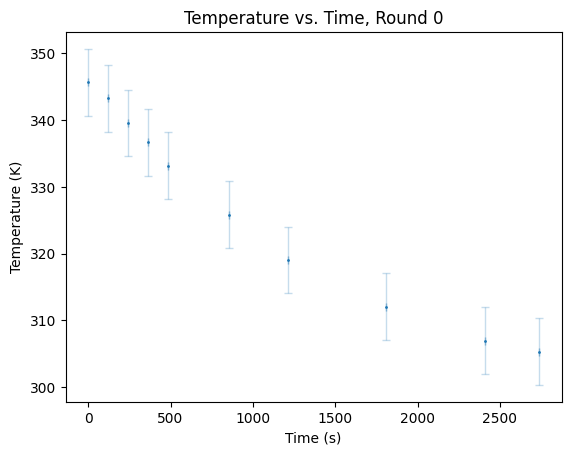

In [19]:
plot_dataset(test_1_data, temperature_curve_gopts)

**Observations:** We can clearly see that theres a decay of some form (not necessarily exponential/logarithmic), so this is a good sign that our data is roughly true to the trend we should have observed. Again, the uncertainties were undoubtedly overestimated because our measurement method was very off, but this is again okay as this dataset is to test our analysis method (like a proof-of-concept).

Now, we can build the differential equation for the rough pipe, knowing that lab temperature is (usually) roughly 25 degrees Celsius, or about 298.15 K (I didn't measure this in-lab, which I will need to do in the future). 

In [20]:
decay_model_1 = CoolingModel(emissivity_guess=0.8, 
                             pipe=materials.rough_pipe,
                             starting_temp=test_1_data.y[0],
                             surround_temp=298.15)
results_1 = autofit(test_1_data, decay_model_1, temperature_curve_gopts)
print_results(decay_model_1, results_1)

,Measurement,Value,Uncertainty,Relative Uncertainty ($\%$):
0,Emissivity,0.233534,0.184837,79.14772


Goodness of Fit: $\chi$² = 0.087

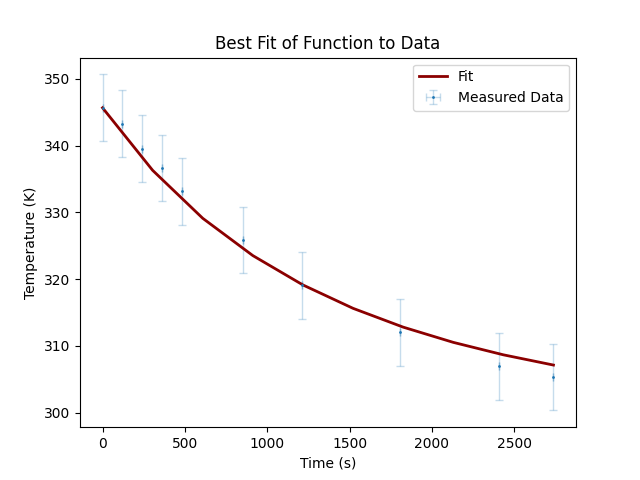

In [21]:
display(results_1.autofit_graph)

**Observation:** It doesn't seem to be fitting the data. Right now, the model is producing $\chi^2=0.307$, indicating that it somewhat fits the data, but reproducing my initial guess with infinite uncertaintiy indicates that the model found that $\chi^2$ is not a function of the emissivity, or that varying the emissivity produced no change in the goodness-of-fit. This is a problem, and I'll need to come back and fix it. 

**Observation (January 14):** OH MY GOD. I WAS USING THE BOLTZMANN CONSTANT INSTEAD OF THE STEFAN-BOLTZMANN CONSTANT. THAT WAS WHY IT WASN'T FITTING. IT FITS PERFECTLY NOW, WITH EXTREMELY LOW UNCERTAINTY!!

Anyway, the $\chi^2$ is now 0.087, proving that the uncertainties were definitely overestimated. Relative uncertainty in this measurement is also quite high, about 79%, so this is by no means an accurate estimation of $\varepsilon$.

## January 10 - Development of an Automatic Data Collection Utility, the TCAT

The goal of this section, prior to the next lab session on Wednesday, January 14, is to develop an automatic data collection/testing utility that is parallelized such that all three temperature curves can be collected simultaneously, easily, and reliably with a small temperature delta (ideally around a second) with well-defined and automatic temperature uncertainty measurement to simplify data collection and save time in-lab. This section will describe my detailed build process in developing the data collection system for in-lab use, which I will refer to as the **Tri-Channel Auto-Thermometer (TCAT)**.

First, the TCAT needs three temperature data collection channels to perform up to three experiments simultaneously. This is done through using three K-type thermocouples as input sensors each connected to a MAX6675 K-thermocouple digitizer as a reciever.

![image.png](./figures/max6675.png)

Each MAX6675 has 5 output pins (similar to the above picture but without the T-, T+, and NC ports): ground (GND), voltage ($V_{CC}$), clock (SCK), chip select (CS), and data (SO). To obtain simultaneous readings from all three channels (thermocouples/MAX6675 chips), each channel is wired to the same clock and data circuits (so there is one shared data read pin on the Arduino and one shared clock pin on the Arduino), and then each channel is given a distinct chip select pin to control which thermocouple is read at a time to only allow one channel to be read at a time (because if more than one channel is read at a time, the data stream will become unintelligble and it will be impossible to distinguish which channel is being read). 

This is accomplished with this Arduino controller code:

```C++
// https://github.com/adafruit/MAX6675-library/tree/master

#include <float.h>

class MAX6675 {
public:
  MAX6675(int8_t clock_pin, int8_t chip_select_pin, int8_t data_output_pin);
  float read_celsius(void);

private:
  uint8_t  clock_pin, chip_select_pin, data_output_pin;
  uint8_t  read_byte(void);
  uint16_t read_spi(void);
};

/*!
 * @brief Initialize a MAX6675 sensor
 * 
 * @param clock_pin       Serial Clock (SCK) pin
 * @param chip_select_pin Chip Select (CS) pin
 * @param data_output_pin Serial Output (SO) pin
 */
MAX6675::MAX6675(int8_t clock_pin, int8_t chip_select_pin, 
  int8_t data_output_pin) 
{
  this->clock_pin       = clock_pin;
  this->chip_select_pin = chip_select_pin;
  this->data_output_pin = data_output_pin;

  pinMode(chip_select_pin, OUTPUT);
  pinMode(clock_pin,       OUTPUT);
  pinMode(data_output_pin, INPUT);

  digitalWrite(chip_select_pin, HIGH);
}

/*!
 * @brief   Returns the temperature in Celsius
 * @returns Temperature in Kelvin or NAN on error
 */
float MAX6675::read_celsius(void) {
  uint16_t raw_digital_output = read_spi();

  /* No thermocouple attached */
  if (raw_digital_output & 0x4)
    /* return junk data, impossible temperature value */
    return NAN;

  return (float) (raw_digital_output >> 3) / 4.0f;
}

/*! 
 * @brief Reads the next two bytes (full SPI output). 
 * @returns The next 16-bit array or NAN on failure.
 */
uint16_t MAX6675::read_spi(void)
{
  uint16_t raw_digital_output;

  digitalWrite(this->chip_select_pin, LOW);
  delayMicroseconds(10);

  /* read the first two bytes to a 2-byte (16-bit) array */
  raw_digital_output = read_byte();
  raw_digital_output <<= 8;
  raw_digital_output |= read_byte();

  digitalWrite(this->chip_select_pin, HIGH);

  return raw_digital_output;
}

/*! @brief   Reads in the next byte from the output pin.
    @returns The next byte or 0 on an error. */
uint8_t MAX6675::read_byte(void) 
{
  uint8_t data = 0;

  for (int i = 7; i >= 0; i--) 
  {
    digitalWrite(this->clock_pin, LOW);
    delayMicroseconds(10);
    if (digitalRead(this->data_output_pin)) {
      // set the bit to 0 no matter what
      data |= (1 << i);
    }

    digitalWrite(this->clock_pin, HIGH);
    delayMicroseconds(10);
  }

  return data;
}

void setup() {
  Serial.begin(9600);
  delay(500);
}

static const uint8_t CLOCK_PIN   = 7;
static const uint8_t DATA_OUTPUT = 6;

static const uint8_t CHIP_SELECT_1 = 4;
static const uint8_t CHIP_SELECT_2 = 3;
static const uint8_t CHIP_SELECT_3 = 2;

MAX6675 tc_1(CLOCK_PIN, CHIP_SELECT_1, DATA_OUTPUT);
MAX6675 tc_2(CLOCK_PIN, CHIP_SELECT_2, DATA_OUTPUT);
MAX6675 tc_3(CLOCK_PIN, CHIP_SELECT_3, DATA_OUTPUT);

void loop() {
  float temp1, temp2, temp3;
  
  temp1 = tc_1.read_celsius();
  temp2 = tc_2.read_celsius();
  temp3 = tc_3.read_celsius();

  Serial.print(temp1);
  Serial.print(',');
  Serial.print(temp2);
  Serial.print(',');
  Serial.print(temp3);
  Serial.println();
 
  /* For the MAX6675 to update, you must 
   * delay AT LEAST 250ms between reads! */
  delay(1000);
}
```

So the TCAT, on USB connection, opens a datastream on serial port `/dev/ttyACM0` by default (or incremented if the port is unavailable) and prints the temperatures as measured by each channel every second (as set by the clock) in the form `T1,T2,T3` in Celsius (as the MAX6675 chip is defined to read in Celsius). These values will need to be manually converted to Kelvin afterward for data analysis.

To read the data out from this data stream, all that needs to happen is that we need to locate the name of the stream which it is printing to (which can be manually done with Arduino Studio or otherwise), then open the stream and read it. Reading data is extremely straightforward: we know that the time delta between measurements is exactly a second, so if we set the first datapoint read as $t=0$, the index of each measurement (the number of measurements before it) is also the number of seconds between that measurement and the first measurement (of course, this carries uncertainty, but this will not be tracked as it has no basis on the ending modeling calculations).

**Uncertainties:** From the MAX6675 K-Type Thermocouple Data Sheet, the uncertainty in the thermocouple at 5 volt VCC measurement between $0^\circ$ C and $+700^\circ $ C is $\pm 9/4 = \pm 2.25$ C/K [[1]](https://www.analog.com/media/en/technical-documentation/data-sheets/max6675.pdf). This means that we can set a standard uncertainty to all measurements performed in lab to be $\pm 2.25$ C/K. (*Continuation, January 14*) The reason why this measurement is 9/4 in particular (and why each measurement has to be divided by 4 in the code, as seen with 
```C++
return (float) (raw_digital_output >> 3) / 4.0f
```
is that the MAX6675 returns integer measurements, so it approximates the temperature to a precision to fractions of 4 by returning only integers that are multiples of four. This means that, even if the temperature sensing on the thermocouples were perfect, there would be an uncertainty of 1/4 K for each measurement, and as the uncertainty in each integer reading is 9, the uncertainty in the temperature reading is 9/4 K.

Now, we can make a function to read the pipe for either a set number of seconds/datapoints, or until all three pipes cool below some "cold" temperature, which is set to $30^\circ C$ by default. This function will read the pipe until hitting its stop condition, then save all of the data to an automatically-generated CSV file.

In [22]:
def read_pipe_to_csv(arduino_port, stop_after=0, 
                     stop_below_temperature=30, uncertainty=9/4, 
                     debug_print=True):
    """
    Read data from Arduino over serial, write to CSV, and stop based on number of points
    or a minimum temperature threshold.

        pipe_title:             Title used in filename.
        arduino_port:           Serial port, e.g., '/dev/ttyACM0'.
        stop_after:             Number of datapoints/seconds to collect; 0 = unlimited.
        stop_below_temperature: Stop if temperature drops below this (in K).
        uncertainty:            Measurement uncertainty to include in CSV.
        debug_print:            Print each line as it's collected.
    """
    # timestamped filename
    now = datetime.now()
    timestamp_str = now.strftime("%Y%m%d_%H%M%S")
    csv_filename = f"./data/test_{timestamp_str}.csv"
    
    print(f"Saving data to: {csv_filename}")
    
    # open serial port
    ser = serial.Serial(arduino_port, 9600, timeout=1)
    time.sleep(2)  # allow Arduino to reset

    # First datapoint is defined as t = 0 seconds
    seconds = 0
    
    try:
        with open(csv_filename, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Temperature 1 (K)', 
                             'Temperature 2 (K)', 
                             'Temperature 3 (K)', 
                             'Uncertainty (K)', 
                             'Time (s)'])
            
            while True:
                # stop based on number of points/seconds
                if stop_after > 0 and seconds >= stop_after:
                    print(f"Reached {stop_after} datapoints/seconds. Stopping.")
                    break
                
                # read line
                line_raw = ser.readline().decode('utf-8').strip()
                if not line_raw:
                    continue
                
                try:
                    temps = np.array([float(token) for token in line_raw.split(",")])
                    
                    # stop based on temperature
                    if np.all(temps < stop_below_temperature) and debug_print:
                        print(f"All temperatures are below {stop_below_temperature:.2f} C. Stopping.")
                        break

                    if debug_print:
                        if stop_after > 0:
                            print(f'{seconds}/{stop_after}', end=' ')
                        print(temps[0], 'C,', temps[1], 'C,', temps[2], 'C')

                    # save to CSV
                    temps = temps + 273.15 
                    writer.writerow([temps[0], temps[1], temps[2], uncertainty, seconds])
                    f.flush()
                    
                    seconds += 1
                    
                except ValueError:
                    continue
                    
    except KeyboardInterrupt:
        print("Stopped by user.")
        
    finally:
        ser.close()
        print("Serial port closed.")

Then, each time, the data can be read (i.e., an experiment can be begun) with something like

```python
read_pipe_to_csv('/dev/ttyACM0')
```

After saving the data to CSV, we can then make a function to read in the test data as CSV and convert it into Dataset objects to be used with the rest of our calculations.

In [23]:
def load_max6675_csv_to_dataset(csv_filename):
    """
    Loads a CSV produced by the MAX6675 Arduino logger into a Dataset object
    using Python's built-in csv module.
    """
    temperatures = [[], [], []]
    times = []
    dy_values = []
    
    with open(csv_filename, newline='') as csvfile:
        reader = csv.reader(csvfile)
        headers = next(reader)  # skip header
        # Identify columns
        try:
            temp_1_idx = headers.index('Temperature 1 (K)')
            temp_2_idx = headers.index('Temperature 2 (K)')
            temp_3_idx = headers.index('Temperature 3 (K)')
            uncert_idx = headers.index( 'Uncertainty (K)')
            time_idx   = headers.index('Time (s)')
        except ValueError:
            raise ValueError("CSV must have headers 'Temperature (K)',  'Uncertainty (K)' and 'Time (s)'")
        
        for row in reader:
            try:
                temp_1 = float(row[temp_1_idx])
                temp_2 = float(row[temp_2_idx])
                temp_3 = float(row[temp_3_idx])
                t  = float(row[time_idx])
                dy = float(row[uncert_idx])
            except ValueError:
                continue  # skip malformed rows
            
            temperatures[0].append(temp_1)
            temperatures[1].append(temp_2)
            temperatures[2].append(temp_3)
            times.append(t)
            dy_values.append(dy)

    datasets = [[],[],[]]
    for i in range(3):
        x = np.array(times)
        y = np.array(temperatures[i])
        dx = np.zeros_like(x)
        dy = np.array(dy_values)

        datasets[i] = Dataset(x=x, dx=dx, y=y, dy=dy)
    
    return datasets

And similarly, we can make a function to plot all three channels simultaneously (without uncertainties, because the error bars would clutter up the graph).

In [24]:
def plot_max6675_datasets(datasets, labels=None):
    """
    Plot multiple MAX6675 datasets on the same axes as lines (no uncertainties).
    """
    plt.figure()

    for i, ds in enumerate(datasets):
        label = labels[i] if labels is not None else f"Channel {i+1}"
        plt.plot(ds.x, ds.y, label=label)

    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (K)")
    plt.title("(TCAT) Temperature vs Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

And we can test this with a simple example dataset of water cooling from being heated.

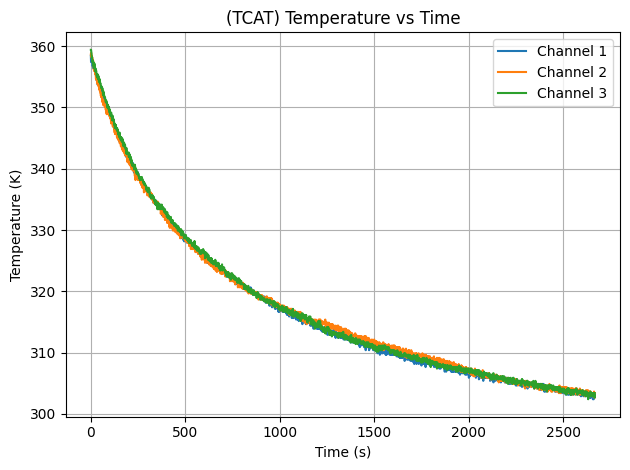

In [25]:
example_cooling_data = load_max6675_csv_to_dataset('./example_tcat_data.csv')
plot_max6675_datasets(example_cooling_data)

**Observation:** Right now, this isn't particularly useful, but having a graph like the above on a parallelized test will allow us to visually inspect the graphs to intuitionally determine what the relationships between the emissivity values should look like, as higher emissivities should have faster decays (or lower relaxation times) and lower emissivities should have slower decays (or higher relaxation time), and this behavior would be visible from the graph. If the channels are then each labelled with their associated finishes, it will be incredibly clear to determine what the relationships in the emissivities should be even without performing any quantitative analysis, and *the ability to perform this kind of qualitative analysis is a major strength of the TCAT*.

**Note: (January 14)** The above figure is *not* a cooling curve of the pipes used, it is a test cooling curve for heated water from my apartment to test the TCAT mechanism.

## January 14 - (Lab Session 2) First Official Parallelized Dataset and Emissivity Relations Exploration

The goal of today's lab session is to obtain a first official dataset for parallelized measurements across the three pipes. The plan is to put all three pipes into the heat bath simultaneously for the same length of time then measure all of them in parallel over the full cooling curve back down to lab temperature (or just above at about 30 degrees Celsius). The hope in doing so is twofold: we want to be able to validate our experimental workflow (meaning ensuring that this data collection process is quantitatively reliable by checking the uncertainties in our measurements) and furthermore, we want to qualitatively analyze the emissivity relationships between the pipes based on the parallel curves we obtain from the measurements and discuss this in relation with our expected relationship between their emissivities (and we can explore a quantitative solution for this relationship later on using the differential equation solver).

### Data Collection, Round 1

In [26]:
temperature_curve_gopts.data_round = 1

We're going to perform a first-round data collection. We've opted to put the rods into the heat bath for 25 minutes at the same time, as measured by a timer, and then we'll take them out and begin parallel temperature measurement on all three using the TCAT. We expect this measurement time to take roughly an hour and a half in total, or about half of the lab time. 

```python
read_pipe_to_csv('/dev/ttyACM0')
```

In this first experiment, we've validated the temperature measurements by also using a second dual-channel thermocouple thermometer connected to the lacquered and polished pipes simultaneously, and we're comparing the temperature readings from this second thermometer to the readings from the TCAT, which we know are in agreement within the uncertainty of the TCAT's readings ($\pm 2.25$ Kelvin).

Our measurement apparatus looks like the following:

<div>
    <br>
    <img src="./figures/apparatus.jpg" width="500"/>
    <br>
</div>

And we can use the manual thermometer to visually validate the output of the TCAT. Furthermore, we keep order of which pipe corresponds with each channel by having labels on each of the TCAT thermocouples designating the thermocouples (and prior to the experiment beginning, we did a small manual test to verify that each of these labels correctly corresponded to each of the measurement channels).

Now, on collecting the data, we've quickly learned that our timescale is probably much larger than necessary, and we're obtaining far more data than is necessary to get accurate results. The cooling time for performing a measurement is far longer than initially expected (I had expected that the cooling time would be about an hour based on a test I performed with boiled water in a water cup, but I didn't take into account that the emissivity of water is about 25 times the emissivity of polished aluminum), so we should probably decrease the timescale to something like 15 seconds or so due to the large amount of duplication/stagnation at lower temperature values as the temperature gradient between the rod and the room further decreases.

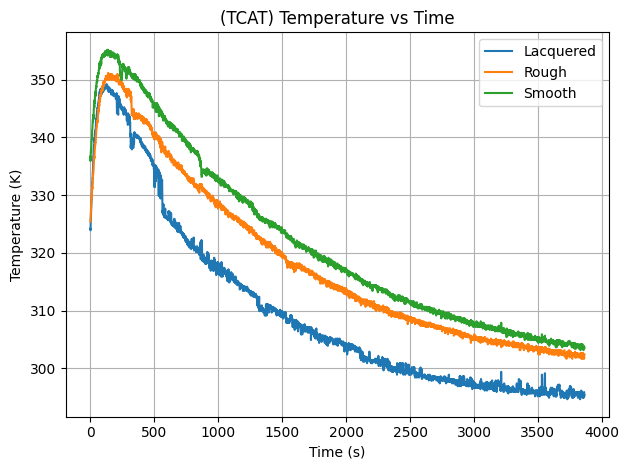

In [27]:
round_1_dataset = load_max6675_csv_to_dataset('./final_data/round_1.csv')
plot_max6675_datasets(round_1_dataset, labels=['Lacquered', 'Rough', 'Smooth'])

**Observations:** We can directly determine the relationships in the emissivities of each of the pipes based on comparing their characteristic cooling curves. The lacquered pipe decreased in temperature the fastest, and then the smooth pipe was the slowest, and the rough pipe was between both curves throughout the experiment. This matches our expectations from literature [[1]](https://www.bergeng.com/mm5/downloads/fluke/Emissivity-Values-of-Common-Materials-Chart.pdf), that being that lacquered alumium would have the highest emissivity and smooth alumium would have the lowest emissivity, with rough alumium between the two.

Note that the uncertainties are not shown on this graph as the general curve is far more important for understanding the relationships (and the uncertainties will be shown on individual graphs for each pipe when solving for the emissivities quantitatively) and that the maximum temperature doesn't accurately represent the starting temperatures of each pipe. Rather, it's the maximum temperature of the thermocouple: each pipe had already begun cooling at vastly different rates due to their different emissivities, so the thermocouple had to heat up to the temperature of the pipe, which takes a period of time. Therefore, temperature readings prior to the maximum temperature for each curve should be ignored for analysis.

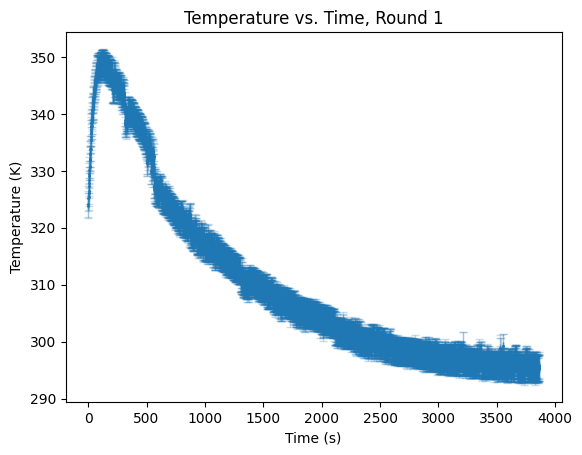

In [28]:
plot_dataset(round_1_dataset[0], temperature_curve_gopts)

**Observation:** This is why the uncertainties were not included. This is what a plot would look like if the uncertainties were added, and it makes the graph extremely cluttered. This is just the dataset for channel one (the lacquered pipe), and for future graphs, I'll need to make some kind of visual distinction (perhaps in opacity) between the measurement and the uncertainty.

Lastly, from the first round of data collection, we're certain that this data collection method was overall successful at performing an automatic experiement (in short, the TCAT was a very, very good idea). The immediate next step is to do a quantitative analysis of each channel and try and approximate the emissivities for each pipe given this data (and to repeat this experiment a few times, at least once per lab session) to further develop our bank of accurate datasets due to the high uncertainty in each individual measurement from the TCAT.

**Sources, Jan 14**

[1] https://www.bergeng.com/mm5/downloads/fluke/Emissivity-Values-of-Common-Materials-Chart.pdf

## January 14 - Short Post-Lab Quantitative Analysis

I realized why my differential equation solver wasn't working while doing some thermodynamic calculations for my ASTR 102 class. I was using the Boltzmann Constant $k_B$ (`scipy.constants.Boltzmann`) instead of the Stefan-Boltzmann Constant $\sigma$ (`scipy.constants.Stefan_Boltzmann`). Ouch. Now the entire solver completely works, so I'll try fitting my data for each!

First, before continuing, I'll simplify the scoping for each round using a structure:

In [29]:
@dataclass
class PipeExperiment:
    raw_data: Dataset = None
    data:     Dataset = None
    model:    CoolingModel = None
    results:  FitModelResult = None
    
    def __init__(self, raw_data, emissivity_guess, pipe, surround_temp=298.15, trim_range=None, plot=False):
        self.raw_data = raw_data
        
        self.data = trim_dataset(
            self.raw_data, 
            trim_range=trim_range, 
            graphing_options=temperature_curve_gopts, 
            plot=plot
        )
        
        self.model = CoolingModel(
            emissivity_guess=emissivity_guess, 
            pipe=pipe,
            starting_temp=self.data.y[0],
            surround_temp=surround_temp
        )
        
    def perform_fit(self):
        self.results = autofit(self.data, self.model, temperature_curve_gopts)
        print_results(self.model, self.results)
        
    def save_to_bank(self, bank):
        bank.push(self.model.values()[0], self.model.uncertainties()[0], self.results.chi2)

I'll also start a measurement bank to record the results from each experiment/dataset.

In [30]:
@dataclass
class MeasurementArray:
    values: np.ndarray = field(default_factory=lambda: np.array([]))
    uncertainties: np.ndarray = field(default_factory=lambda: np.array([]))
    relative_uncertainties: np.ndarray = field(default_factory=lambda: np.array([]))
    chi_squareds: np.ndarray = field(default_factory=lambda: np.array([]))
    
    def push(self, value, uncertainty, chi2):
        self.values = np.append(self.values, value)
        self.uncertainties = np.append(self.uncertainties, uncertainty)
        self.relative_uncertainties = np.append(self.relative_uncertainties, uncertainty/value)
        self.chi_squareds = np.append(self.chi_squareds, chi2)
        
    def plot(self, graphing_options, color, label):
        graphing_options.plot_data(
            self.chi_squareds, 
            self.values, 
            np.zeros_like(self.chi_squareds), 
            self.uncertainties,
            label=label,
            color=color
        )
        
    def expectation(self):
        return np.mean(self.values)

emissivity_bank_graphing_options = GraphingOptions(
    x_label = 'Goodness of Fit $\\chi^2$',
    y_label = 'Emissivity $\\varepsilon$',
    x_units = None,
    y_units = None
)
        
@dataclass
class EmissivityBank:
    lacquered: MeasurementArray = field(default_factory=MeasurementArray)
    rough: MeasurementArray     = field(default_factory=MeasurementArray)
    smooth: MeasurementArray    = field(default_factory=MeasurementArray)
    
    def tabulate(self):
        rows = []

        for surface_name, measurement_array in {
            "Lacquered": self.lacquered,
            "Rough": self.rough,
            "Smooth": self.smooth,
        }.items():

            n = len(measurement_array.values)
            for i in range(n):
                rows.append({
                    "Surface": surface_name,
                    "Round": i+1,
                    "Emissivity": measurement_array.values[i],
                    "Uncertainty": measurement_array.uncertainties[i],
                    "Relative Uncertainty": measurement_array.relative_uncertainties[i],
                    "Relative Uncertainty ($\\%$)": measurement_array.relative_uncertainties[i] * 100,
                    "$\\chi^2$": measurement_array.chi_squareds[i]
                })

        return pd.DataFrame(rows)
    
    def plot(self):
        plt.figure()
        plt.title('Emissivity Values')

        self.lacquered.plot(emissivity_bank_graphing_options, color='orange', label='Lacquered')
        self.rough.plot(emissivity_bank_graphing_options, color='green', label='Rough')
        self.smooth.plot(emissivity_bank_graphing_options, color='blue', label='Smooth')
        
        emissivity_bank_graphing_options.set_labels()
        plt.legend()
        plt.show()
    
    def plot_by_round(self):
        plt.figure()
        plt.title('Emissivity by Round')
        
        xvals = np.arange(lacquered.values.size)
        
        plt.errorbar(x=xvals, y=lacquered.values, dy=lacquered.uncertainties)
        plt.
    
    def show(self):
        display(self.tabulate())
    
bank = EmissivityBank()

**Lacquered Pipe:**

First, I need to truncate each of the datasets to not include anything before the maximum point. They are all decreasing around the 300th data entry, so we can try trimming the dataset:

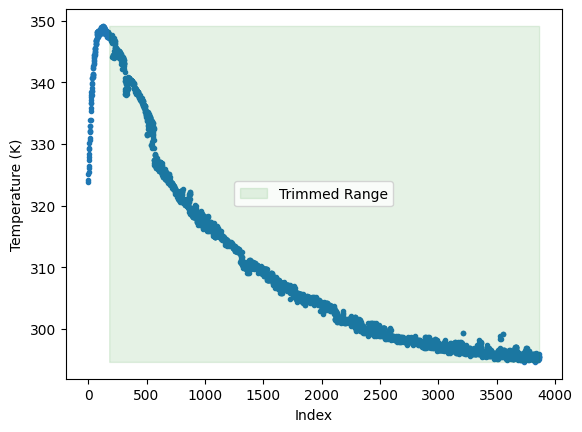

In [31]:
round_1_lacquered = PipeExperiment(
    raw_data = round_1_dataset[0],
    emissivity_guess = 0.8,
    pipe = materials.lacquered_pipe,
    trim_range = (180,4000),
    plot = True
)

For my initial emissivity guess, I'll just guess 0.8 from literature (somewhere between 0.45 and 1.0), and see how it ends up comparing.

In [32]:
round_1_lacquered.perform_fit()
round_1_lacquered.save_to_bank(bank.lacquered)

,Measurement,Value,Uncertainty,Relative Uncertainty ($\%$):
0,Emissivity,1.0,0.006488,0.648816


Goodness of Fit: $\chi$² = 2.423

**Observations:** This model seems to almost match the data. The autofit produced $\chi^2 = 2.423$, which indicates an imperfect but fairly close fit. More importantly, the model determined that the lacquered pipe is a perfect emitter with an emissivity of $\varepsilon = 1 \pm 0.0065$, so the relative uncertainty in this measurement is $0.65\%$, which is extremely low. However, this result is not in-line with the literature expectations. Before constricting the domain of the fit, the model approximated the emissivity to be around $\varepsilon \approx 1.5$, and literature predictions for a lacquered alumium pipe as such are for the pipe to be somewhere between 0.45 and 0.95, so at best, we'd expect some imperfection. The high certainty in this value is likely a reflection of the low relative uncertainty in the data (the minimum relative uncertainty is at standard lab temperature around 300 Kelvin, or around $0.75\%$ for each measurement), and likely not a reflection of the model itself.

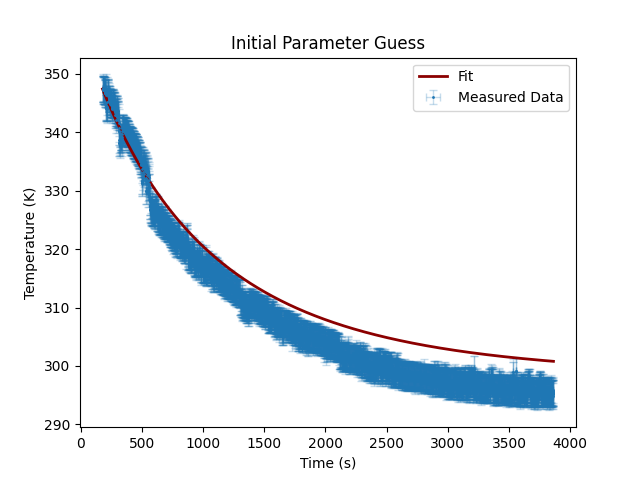

In [33]:
display(round_1_lacquered.results.initial_guess_graph)

**Observation:** The initial guess actually was not bad. We can obviously tell that increasing $\varepsilon$ will twist the curve downward (increase the rate of temperature decrease), thus why higher $\varepsilon$ matches the graph better.

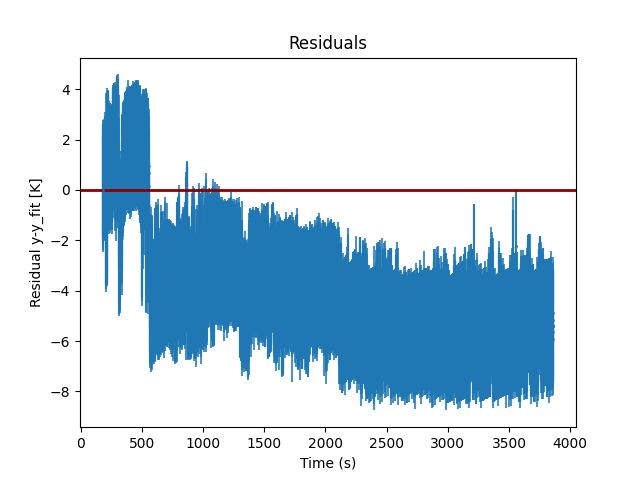

In [34]:
display(round_1_lacquered.results.initial_guess_residuals_graph)

**Observations:** The goal of increasing $\varepsilon$ is essentially to move the model fit line (at $y=0$) downward to better match this data. Interestingly, we have a starting region shifted much higher than the other regions (differing around $t=500$ seconds). Perhaps we could perform another directed fit on just the data beyond $t=500$ seconds and see if this produces a more accurate $\varepsilon$?

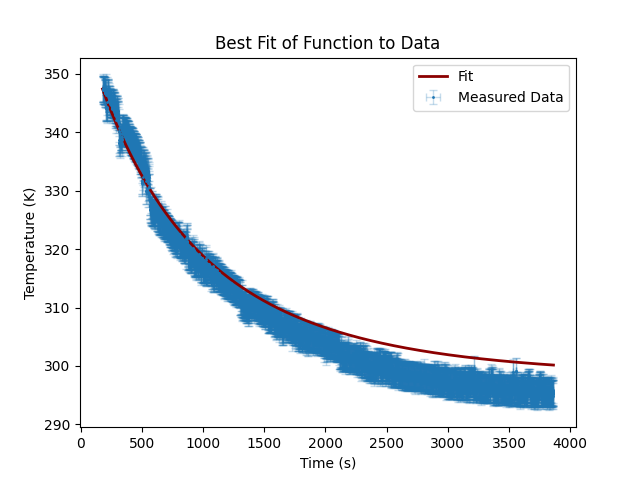

In [35]:
display(round_1_lacquered.results.autofit_graph)

**Observations:** The autofit graph clearly deviates much more at later times, and this is to be expected because the cooling model is a forward-solved differential equation, so the error in the solution compounds with increased time.

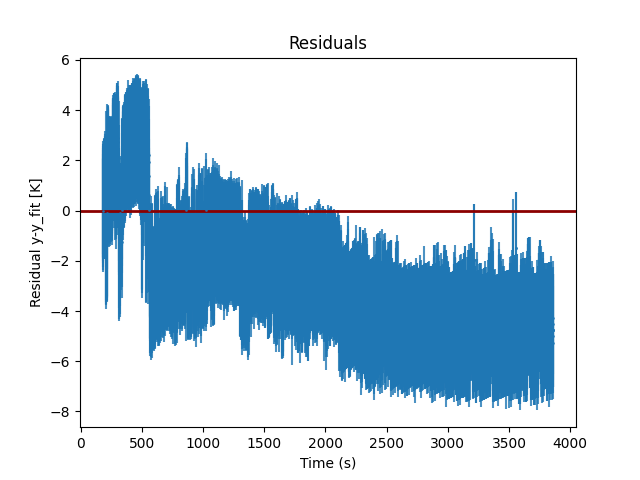

In [36]:
display(round_1_lacquered.results.autofit_residuals_graph)

**Observations:** Once again, it may be fruitful to fit the tailend of this dataset after around $t=500$ seconds or so.

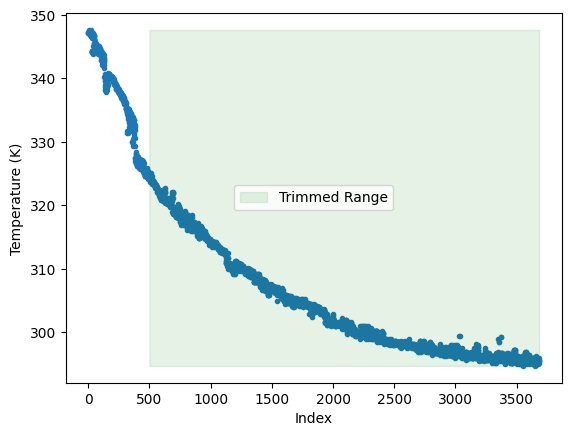

In [37]:
round_1_lacquered_refitted = PipeExperiment(
    raw_data = round_1_lacquered.data,
    emissivity_guess = 0.8,
    pipe = materials.lacquered_pipe,
    trim_range = (500,4000),
    plot = True
)

In [38]:
round_1_lacquered_refitted.perform_fit()

,Measurement,Value,Uncertainty,Relative Uncertainty ($\%$):
0,Emissivity,1.0,0.011327,1.132674


Goodness of Fit: $\chi$² = 2.159

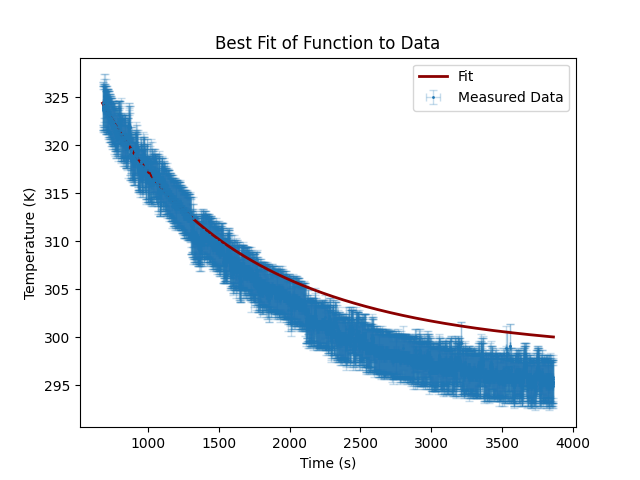

In [39]:
display(round_1_lacquered_refitted.results.autofit_graph)

**Observation:** It didn't seem to help at all to remove the initial section. In fact, the fit got worse, increasing in relative uncertainty without any change to the emissivity value. I suppose that this is the result of error in the forward model: the model is much better at fitting initial values to begin with. In that case, what if I only fit the initial section, with a slight bit of overlap?

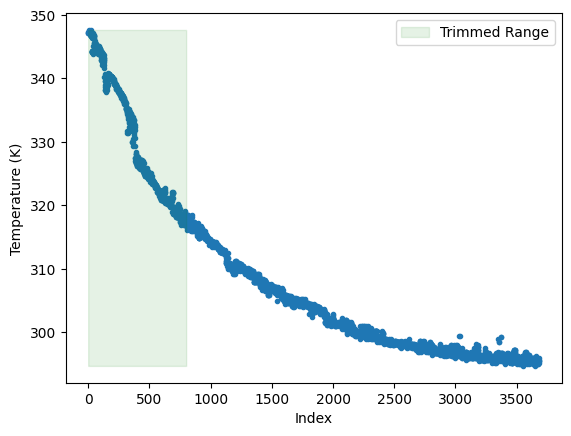

In [40]:
round_1_lacquered_refitted_2 = PipeExperiment(
    raw_data = round_1_lacquered.data,
    emissivity_guess = 0.8,
    pipe = materials.lacquered_pipe,
    trim_range = (0,800),
    plot = True
)

In [41]:
round_1_lacquered_refitted_2.perform_fit()

,Measurement,Value,Uncertainty,Relative Uncertainty ($\%$):
0,Emissivity,1.0,0.013472,1.34724


Goodness of Fit: $\chi$² = 0.942

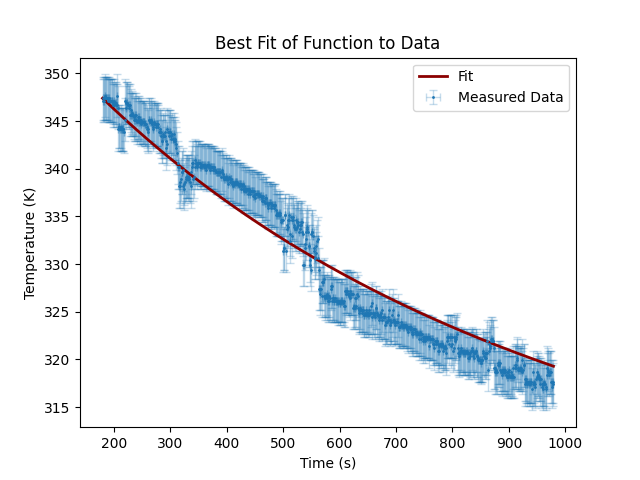

In [42]:
display(round_1_lacquered_refitted_2.results.autofit_graph)

**Observation:** Once again, it's getting the same emissivity of $\varepsilon=1$, but this time, it got the best $\chi^2$ value at $\chi^2=0.942$ but this has higher uncertainty in the emissivity than where we started. Altogether, we can conclude that changing the section of data to model isn't positively affecting the goodness-of-fit, so there is no point in modeling specific sections here.

**Rough Pipe:**

For this initial guess value, I'll just use the value obtained from my previous manual dataset.

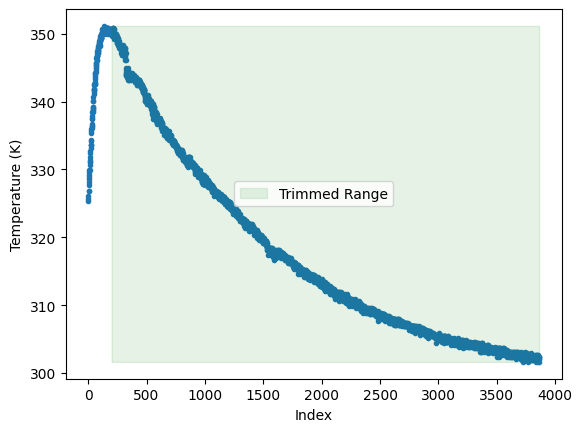

In [43]:
round_1_rough = PipeExperiment(
    raw_data = round_1_dataset[1],
    emissivity_guess = 0.23,
    pipe = materials.rough_pipe,
    trim_range = (200,4000),
    plot = True
)

In [44]:
round_1_rough.perform_fit()
round_1_rough.save_to_bank(bank.rough)

,Measurement,Value,Uncertainty,Relative Uncertainty ($\%$):
0,Emissivity,0.309526,0.003726,1.203806


Goodness of Fit: $\chi$² = 0.266

**Observation:** This dataset produces a much better fit compared to the lacquered dataset, as it obtained $\chi^2=0.266$. It obtained an emissivity of $\varepsilon = 0.3095 \pm 0.0037$, which is a fairly precise measurement at a relative uncertainty of about $1.2\%$.

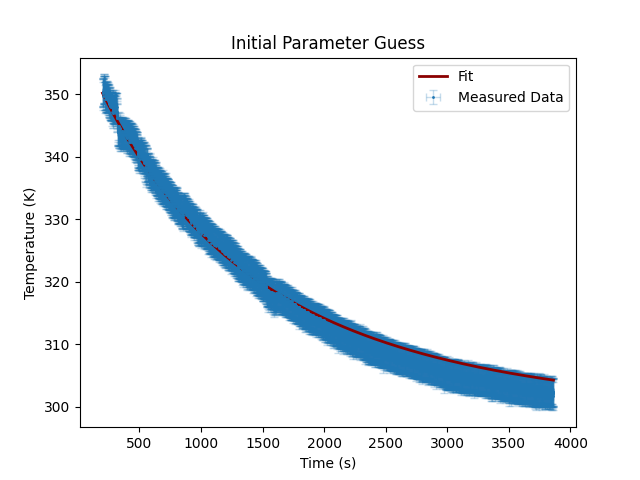

In [45]:
display(round_1_rough.results.initial_guess_graph)

**Observation:** It seems that the initial guess was fairly accurate, at least within the uncertainty of the dataset, so the data collected from the manual data collection test was reasonably accurate.

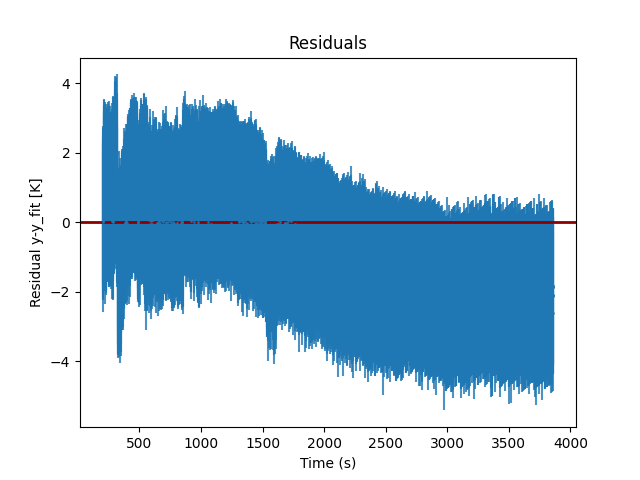

In [46]:
display(round_1_rough.results.initial_guess_residuals_graph)

**Observation:** Again, we can see that the model is able to fit all of the data points within their uncertainty, but it doesn't appear to be centered within the residuals.

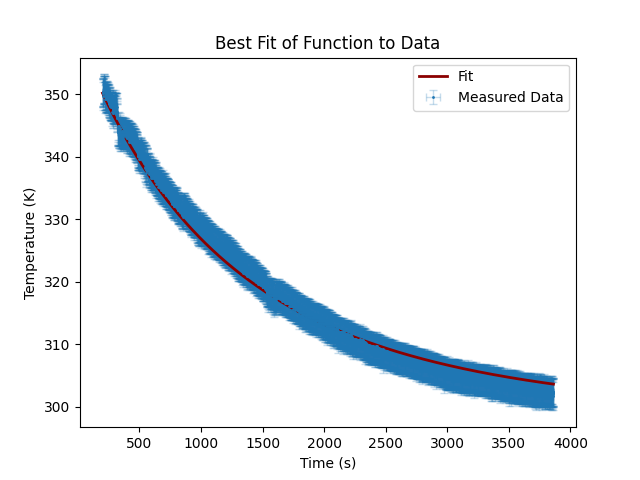

In [47]:
display(round_1_rough.results.autofit_graph)

**Observation:** This is clearly slightly better. Again, the model is within the residuals over all points, but it clearly matches the curve much better at farther times, which is much more critical, as the later times are more prone to error from the forward model.

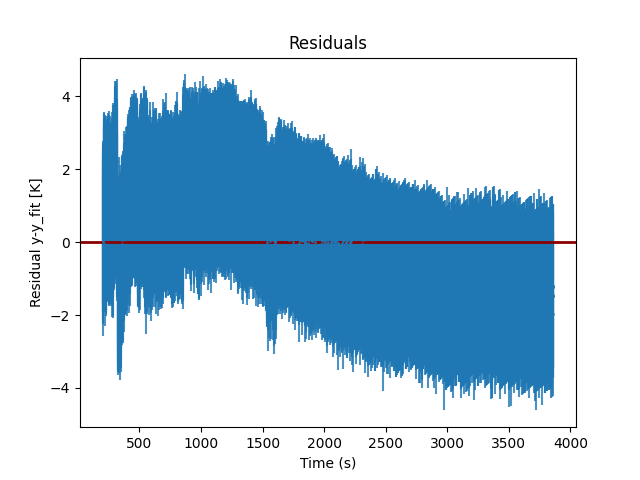

In [48]:
display(round_1_rough.results.autofit_residuals_graph)

**Observation:** Once more, we can see that the model residual line seems near-perfectly centered within the residual distribution.

**Smooth Pipe:**

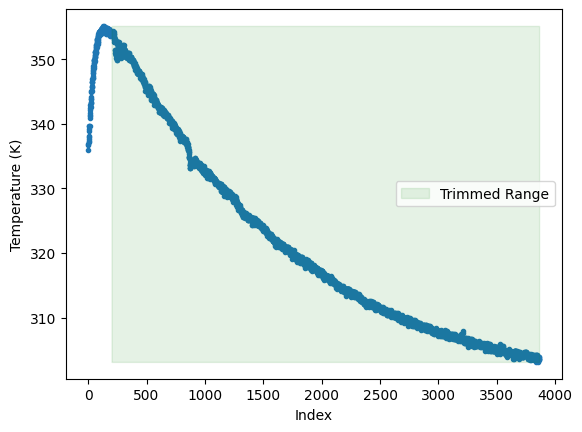

In [49]:
round_1_smooth = PipeExperiment(
    raw_data = round_1_dataset[2],
    emissivity_guess = 0.1,
    pipe = materials.rough_pipe,
    trim_range = (200,4000),
    plot = True
)

In [50]:
round_1_smooth.perform_fit()
round_1_smooth.save_to_bank(bank.smooth)

,Measurement,Value,Uncertainty,Relative Uncertainty ($\%$):
0,Emissivity,0.119525,0.002963,2.479246


Goodness of Fit: $\chi$² = 0.440

**Observation:** This model produced the best fit with the $\chi^2=0.44$ (the closest to $\chi^2=1$), seemingly due to having the lowest emissivity value of $\varepsilon=0.1195 \pm 0.0030$ (but not the lowest relative uncertainty, at about $2.5\%$). We can then understand that the higher the emissivity, the harder it is to accurately model its cooling curve.

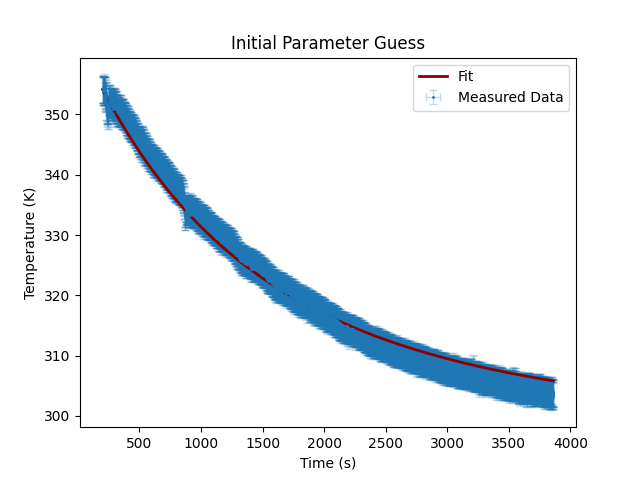

In [51]:
display(round_1_smooth.results.initial_guess_graph)

**Observation:** The initial guess of $\varepsilon=0.1$ was already fairly close to begin with, as it seems to already exist within the range of the uncertainty of the dataset.

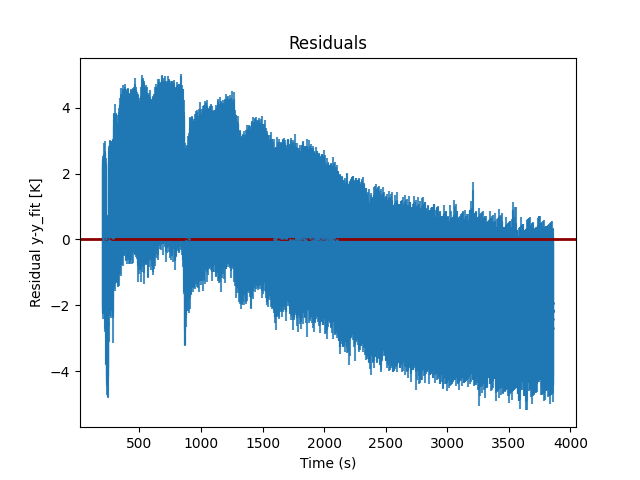

In [52]:
display(round_1_smooth.results.initial_guess_residuals_graph)

**Observation:** The initial guess was seemingly so good that it's almost perfectly centered to begin with. The only thing to change is some slight fine-tuning to be perfectly aligned to the center of the residuals, thus why the final value was only $\Delta \varepsilon = +0.0195$ off from the initial guess.

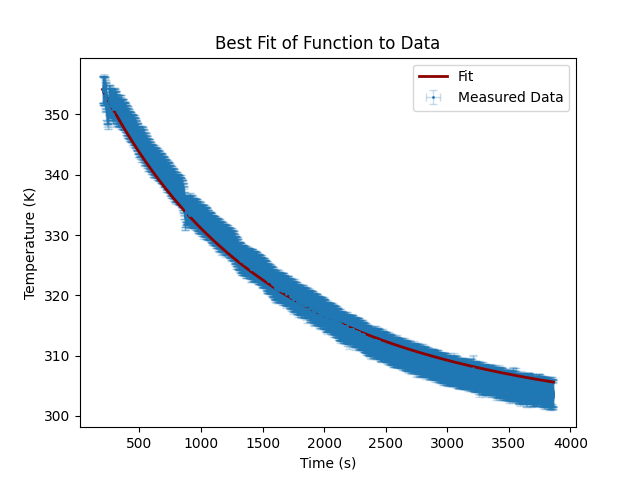

In [53]:
display(round_1_smooth.results.autofit_graph)

**Observation:** Once again, the autofit exists entirely within the uncertainty range of the dataset, just overestimating the data toward the end of the curve and underestimating the temperature at the beginning of the distribution.

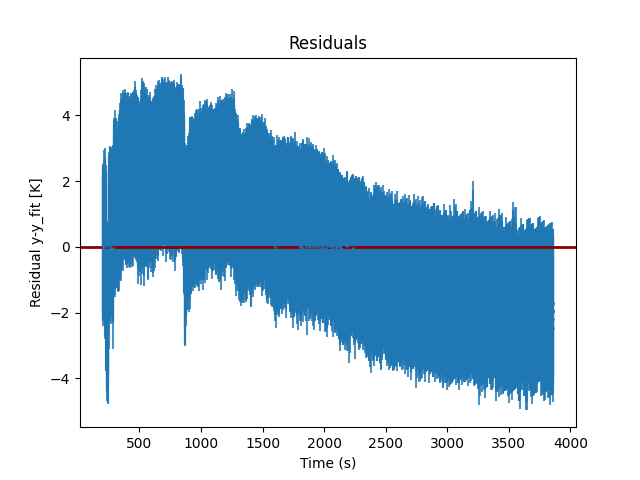

In [54]:
display(round_1_smooth.results.autofit_residuals_graph)

**Observation:** Altogether, the final curve exists just around the middle of the residual distribution.

The final takeaway from this is that quantitatively, the expectations from literature match the data we're collecting. What is interesting, however, is that the models have a tendency to underestimate data at early times and overestimate data at later times, and this may be the result of the model's parameters being imprecise or the model itself missing key considerations (for example, we've assumed that conduction willbe negligible, but it may not necessarily be so). The best way to further this investigation would be to try and explore the cooling curve by examinng each heat transfer mode separately, and this would require a dataset on any of the three pipes to be broken into each of the three modes to determine which transfer mode is the most dominant of the three in this scenario. 

Lastly, let's take a look at what we've collected in our databank thus far:

In [55]:
bank.show()

,Surface,Round,Emissivity,Uncertainty,Relative Uncertainty,Relative Uncertainty ($\%$),$\chi^2$
0,Lacquered,1,1.000000,0.006488,0.006488,0.648816,2.423327
1,Rough,1,0.309526,0.003726,0.012038,1.203806,0.266352
2,Smooth,1,0.119525,0.002963,0.024792,2.479246,0.439951


The goal of this databank is to collect each emissivity value we obtain for each pipe in each round, then at the end of all of each experimental round, we can compare the results against their $\chi^2$ to get a good understanding of what the emissivity is most likely to be for each pipe. As I continue with this notebook, this table should grow considerably, adding three rows for each data collection round.

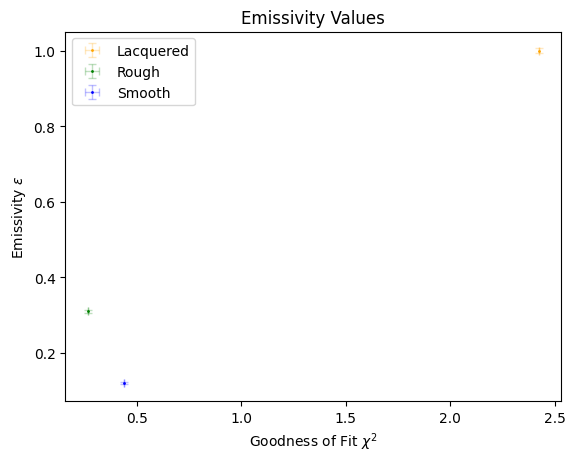

In [56]:
bank.plot()

As we continue on with each data round, we're going to continue to add new data to this bank and replot each time to visually see if there are any additional trends that spring up here. With that, I hope to try and get at least 5 rounds of good data ($10^{-2} < \chi^2 < 10$ for all points) to see what results we get.

## January 21 - Continued Data Collection

(Note) Rather than decreasing the volume of collected data by 15, I've instead decided to switch to keeping the data at its present volume and packing the data instead to reduce uncertainty.

### Data Collection, Round 2

In [57]:
temperature_curve_gopts.data_round = 2

To begin, we've performed our initial TCAT test to ensure that the channels are correct by blowing on the thermocouple channels of the TCAT to witness a temperature response, and we've confirmed that the temperature readings are accurate against standard lab temperature. Therefore, we can begin to move further into the experiment.

The only goal for today's lab is to continue our data collection by obtaining an additional round of data. As shown in the previous session, the boiling time in the heat bath does not need to be very long, so we will only put the rods in for a total of 10 minutes to maximize collection time. Otherwise, measurement will be exactly the same as the previous round. Upon obtaining the data and fitting it, we plan to compare against our previous results and log these results in the emissivity bank.

For round 2, we've placed the smooth pipe on channel 1, the lacquered pipe on channel 2, and the rough pipe on channel 3. I don't have my packing function complete right now, so I'll perform the fit in the same manner as round 1 (unpacked). 

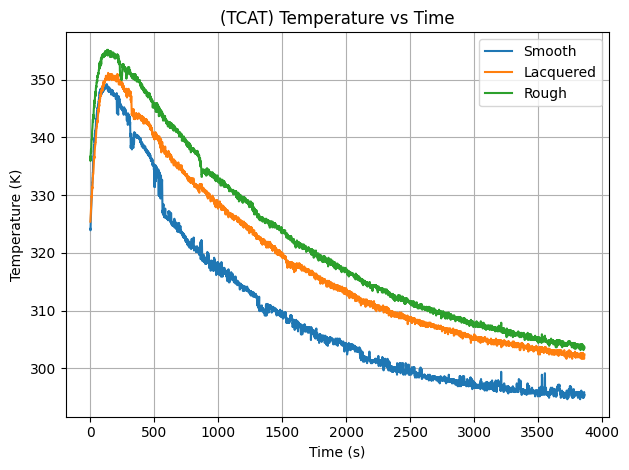

In [58]:
round_2_dataset = load_max6675_csv_to_dataset('./final_data/round_2.csv')
plot_max6675_datasets(round_1_dataset, labels=['Smooth', 'Lacquered', 'Rough'])

**Observations:** The curves don't seem to match qualitative expectations. One would think that the smooth pipe would be on the top, the rough pipe would be in the middle, and the lacquered pipe would be on the bottom. However, this is not what we are seeing. A possible explanation for this behavior is differences in the starting temperature. As we left the pipe in for a short period of time as compared to the original case, a pipe like the smooth pipe, will have heated to a much lower starting value as compared to the rough or lacquered pipes. Another potential problem is the immense uncertainty, which can be curbed by decreasing the time delta on each measurement then packing the data to reduce the uncertainty in the full measurement.

For each additional round, we'll set our initial guess (expectation value) to be the mean of the previously collected datapoints. In the case of round 2, this is just the previous measured emissivity.

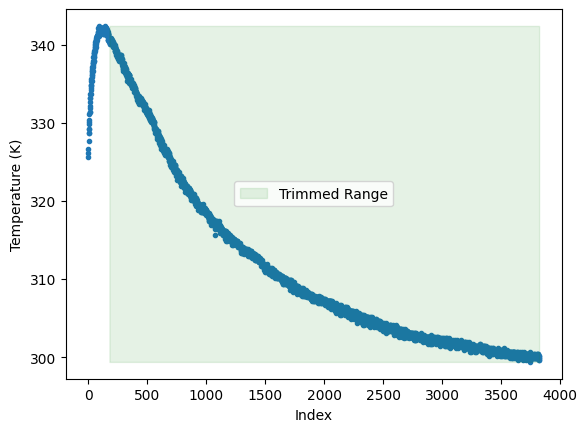

In [59]:
round_2_lacquered = PipeExperiment(
    raw_data = round_2_dataset[1],
    emissivity_guess = bank.lacquered.expectation(),
    pipe = materials.lacquered_pipe,
    trim_range = (180,4000),
    plot = True
)

In [60]:
round_2_lacquered.perform_fit()
round_2_lacquered.save_to_bank(bank.lacquered)

,Measurement,Value,Uncertainty,Relative Uncertainty ($\%$):
0,Emissivity,0.755735,0.006233,0.824815


Goodness of Fit: $\chi$² = 0.112

**Observations:** The lacquered pipe obtained $\varepsilon = 0.7557 \pm 0.0062$ for a relative uncertainty of $0.82\%$ and $\chi^2 = 0.112$, so the fit matches the data, but the uncertainties are likely overestimated. As stated before, to curb this overestimated uncertainty, this data should likely be packed (and if I do perform a packed set, I will have to go back through and remake the databank based only on packed data). 

This emissivity is a roughly 1/4 decrease compared to the perfect emitter prediction from the previous model (and furthermore, the previous model predicted a nonrealistic emissivity of approximately 1.5 when optimized without bounds), so this is a fairly drastic decrease in estimation. Given the low $\chi^2$ in this model and low uncertainty in the emissivity, however, this measurement is higher in precision compared to the previous measurement, indicating potentially better results.

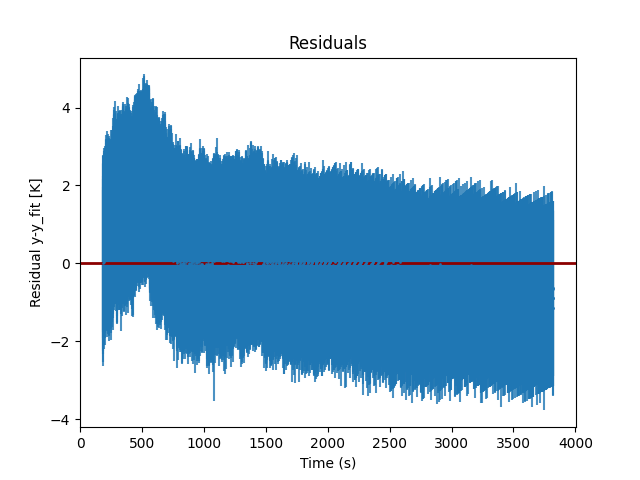

In [69]:
display(round_2_lacquered.results.autofit_residuals_graph)

**Observations:** From the residuals graph of the autofit, we can see that the model is able to bisect the data without a trend, indicating that the model is successfully fitting the data. Unfortunately, again, the uncertainties look quite large given the mode, as there is clearly a large region for models that can successfully fit the data.

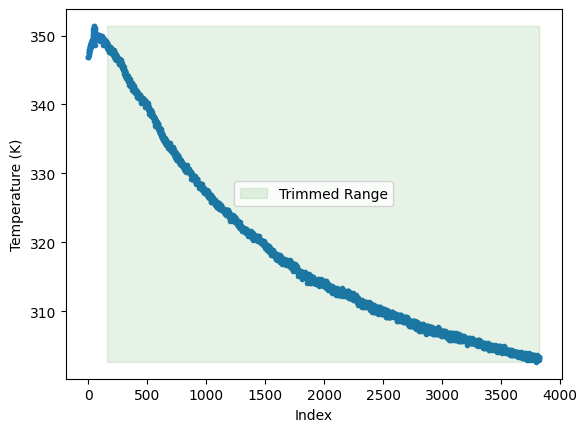

In [61]:
round_2_smooth = PipeExperiment(
    raw_data = round_2_dataset[0],
    emissivity_guess = bank.smooth.expectation(),
    pipe = materials.smooth_pipe,
    trim_range = (160,4000),
    plot = True
)

In [62]:
round_2_smooth.perform_fit()
round_2_smooth.save_to_bank(bank.smooth)

,Measurement,Value,Uncertainty,Relative Uncertainty ($\%$):
0,Emissivity,0.192876,0.00346,1.793981


Goodness of Fit: $\chi$² = 0.124

**Observations:** This model produced $\varepsilon = 0.1929 \pm 0.0034$ with a relative uncertainty of $1.79\%$ and $\chi^2 = 0.124$, indicating again that the uncertainties are quite high but the model is certain in this estimation of emissivity. 

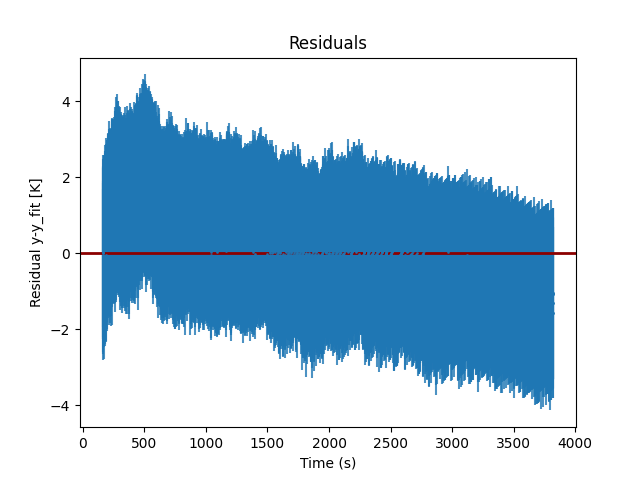

In [70]:
display(round_2_smooth.results.autofit_residuals_graph)

**Observations:** Once again, the autofit residuals graph shows a fairly well-bisected data given the model, but the high uncertainty means that there is clearly a range in which many distinct models can reasonably fit the data.

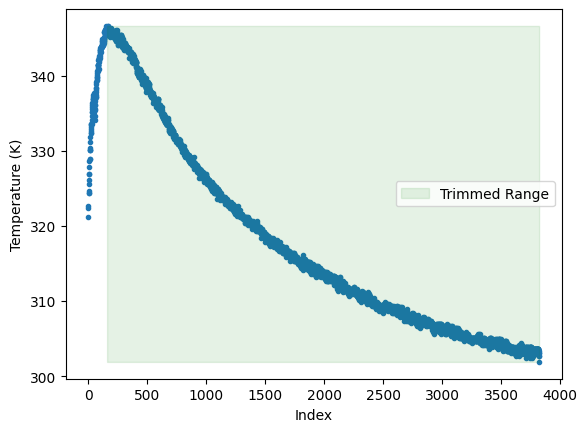

In [63]:
round_2_rough = PipeExperiment(
    raw_data = round_2_dataset[1],
    emissivity_guess = bank.rough.expectation(),
    pipe = materials.rough_pipe,
    trim_range = (160,4000),
    plot = True
)

In [64]:
round_2_rough.perform_fit()
round_2_rough.save_to_bank(bank.rough)

,Measurement,Value,Uncertainty,Relative Uncertainty ($\%$):
0,Emissivity,0.183645,0.003586,1.952783


Goodness of Fit: $\chi$² = 0.271

In [65]:
bank.show()

,Surface,Round,Emissivity,Uncertainty,Relative Uncertainty,Relative Uncertainty ($\%$),$\chi^2$
0,Lacquered,1,1.000000,0.006488,0.006488,0.648816,2.423327
1,Lacquered,2,0.755735,0.006233,0.008248,0.824815,0.112027
2,Rough,1,0.309526,0.003726,0.012038,1.203806,0.266352
3,Rough,2,0.183645,0.003586,0.019528,1.952783,0.271160
4,Smooth,1,0.119525,0.002963,0.024792,2.479246,0.439951
5,Smooth,2,0.192876,0.003460,0.017940,1.793981,0.123508


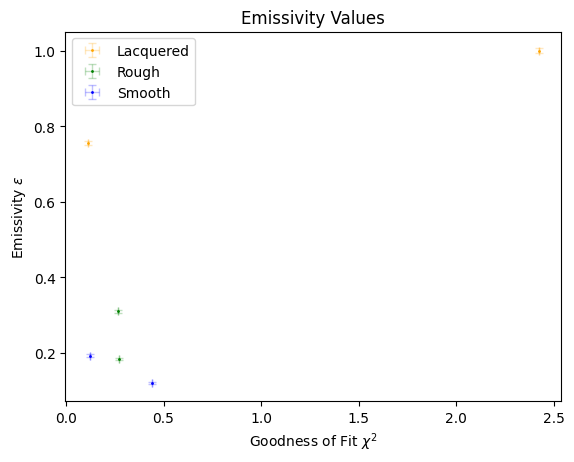

In [66]:
bank.plot()

Altogether, we were successfully able to get the latest round of data. All that is left to do is to decrease the time delta then implement packing to decrease the uncertainty, as the low $\chi^2$ in each plot showed that the uncertainties are likely overestimated.

For round 3, lacquered is channel 1, smooth is channel 2, and rough is channel 3.